In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.utils.data
from torch.utils.data import DataLoader 
from PIL import Image
from matplotlib import pyplot as plt
import seaborn as sns
import wandb
import math
import argparse
import datetime
import math
from time import time
from scipy import stats


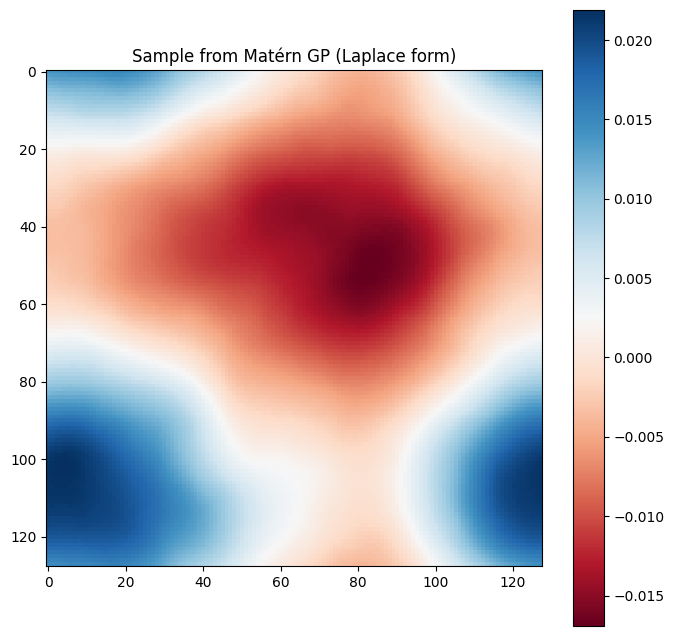

tensor(7.2577e-05)

In [53]:

# def generate_matern_laplace(num_samples, grid_size, sigma_sq, length_scale, s, seed=None):
#     """
#     Generate Matérn GP samples using spectral method
    
#     The Matérn covariance in spectral domain is:
#     S(k) = σ² * (2^d * π^(d/2) * Γ(ν+d/2) * (2ν)^ν) / (Γ(ν) * κ^(2ν)) * (2ν/κ² + 4π²|k|²)^(-ν-d/2)
    
#     For simplicity, we use: S(k) ∝ (κ² + 4π²|k|²)^(-s) where κ = 1/length_scale
#     """
#     if seed is not None:
#         torch.manual_seed(seed)
    
#     # Create frequency grid in correct units
#     # fftfreq gives frequencies in cycles per sample
#     # For a grid of size N, frequencies range from -N/2 to N/2
#     freqs = torch.fft.fftfreq(grid_size, d=1.0)
#     kx = freqs.view(-1, 1).repeat(1, grid_size)
#     ky = freqs.view(1, -1).repeat(grid_size, 1)
    
#     # Compute |k|² (in units of 1/grid_spacing)
#     k_squared = kx**2 + ky**2
    
#     # Matérn spectral density
#     # Using κ = 1/length_scale (inverse length scale)
#     kappa = 1.0 / length_scale
#     spectral_density = sigma_sq * (kappa**2 + k_squared)**(-s)
    
#     # Handle DC component
#     spectral_density[0, 0] = 0
    
#     # Expand for batch dimension
#     spectral_density = spectral_density.unsqueeze(0).repeat(num_samples, 1, 1)
    
#     # Generate complex white noise in Fourier domain
#     # For real-valued output, need to ensure Hermitian symmetry
#     noise_real = torch.randn(num_samples, grid_size, grid_size)
#     noise_imag = torch.randn(num_samples, grid_size, grid_size)
#     noise_complex = torch.complex(noise_real, noise_imag)
    
#     # Apply coloring: multiply by sqrt of spectral density
#     colored_noise = torch.sqrt(spectral_density) * noise_complex
    
#     # Transform to spatial domain
#     # Use 'ortho' normalization for proper scaling
#     spatial_sample = torch.fft.ifft2(colored_noise, norm='ortho')
    
#     # Take real part (imaginary should be ~0 due to construction)
#     sample = spatial_sample.real
    
#     # Normalize to have zero mean and unit variance
#     sample = sample - sample.mean(dim=(1, 2), keepdim=True)
#     sample = sample / sample.std(dim=(1, 2), keepdim=True)
    
#     return sample





# using the generate_matern_laplace from the github repo of Scale-Adaptive Generative Flows for Multiscale Scientific Data
# with no differences. The two things I was worried about while doing this is:
# 1. the multiplication by grid size for the fft frequencies
# 2. the l not being inversely related (1/l^2) to the spectral density

def generate_matern_laplace(num_samples, grid_size, sigma_sq=1.0, length_scale=1.0, s=2.0, seed=None):
    """
    Generate Matérn GP using the operator form σ²(-Δ + l²I)^{-s}
    We are sampling a 0 mean GRF on a 2d grid. The fourier spectrum of the domain is s(k) above.

    
    Args:
        grid_size (int): Size of the grid (N x N)
        sigma_sq (float): Variance parameter σ²
        length_scale (float): Length scale l
        s (float): Smoothness parameter s
        seed (int): Random seed for reproducibility
    
    Returns:
        torch.Tensor: Sample from the GP
    """
    if seed is not None:
        torch.manual_seed(seed)
    
    # Generate frequency grid (scaled by 2π)
    freq = torch.fft.fftfreq(grid_size) * 2 * math.pi * grid_size # returns angular frequency -> these are the units of the spectra
    freq_x, freq_y = torch.meshgrid(freq, freq, indexing='ij')
    
    # Compute -Laplacian in Fourier space: |k|²
    laplacian = freq_x**2 + freq_y**2
    
    # Compute spectral density: σ²(|k|² + l²)^{-s}
    spectral_density = sigma_sq * (laplacian + (length_scale**2))**(-s)
    spectral_density[0,0]= 0
    spectral_density = spectral_density.unsqueeze(0)  # adding 1 dim
    
    
    # Generate complex Gaussian noise
    noise_real = torch.randn(num_samples, grid_size, grid_size)
    noise_imag = torch.randn(num_samples, grid_size, grid_size)
    noise = noise_real + 1j * noise_imag
    
    # Apply sqrt of spectral density
    spectral_sample = torch.sqrt(spectral_density) * noise
    
    # Transform back to spatial domain
    sample = torch.fft.ifft2(spectral_sample, norm='forward')
    sample = sample.real
    
    return sample


def plot_sample(sample):
    """Plot a sample from the GP"""
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(8, 8))
    plt.imshow(sample.numpy(), cmap='RdBu')
    plt.colorbar()
    plt.title('Sample from Matérn GP (Laplace form)')
    plt.show()

# Example usage

grid_size = 128
sample = generate_matern_laplace(
    num_samples=1000,
    grid_size=grid_size,
    sigma_sq=1,
    length_scale=1.0,
    s=3,
    seed=42
)

# Plot the sample
plot_sample(sample[0,...])
# (sample[:,...]**2).mean()

spatial_variance = (sample**2).mean(dim=(1, 2))
spatial_variance.mean()

In [ ]:
# 
def generate_multiscale_dataset_with_spectra(
    num_samples: int,
    grid_size: int,
    coarse_params: dict,
    fine_params: dict,
    mix_coarse: float = 1.0,
    mix_fine: float = 0.6,
    seed: int | None = None,
    normalize: bool = True,
):
    """
    Generate multiscale dataset while tracking individual components and their Fourier spectra.
    
    Returns a dictionary containing:
        - 'combined': The final multiscale field (same as generate_multiscale_matern output)
        - 'coarse': The coarse-scale component before mixing
        - 'fine': The fine-scale component before mixing
        - 'coarse_fft': Fourier transform of coarse component
        - 'fine_fft': Fourier transform of fine component
        - 'combined_fft': Fourier transform of combined field
        - 'normalization': Dict with mean/std used for normalization (if normalize=True)
    """
    import torch
    
    seed0 = seed
    seed1 = None if seed is None else seed + 10_000

    # Generate individual components
    x_coarse = generate_matern_laplace(
        num_samples=num_samples,
        grid_size=grid_size,
        seed=seed0,
        **coarse_params,
    )
    x_fine = generate_matern_laplace(
        num_samples=num_samples,
        grid_size=grid_size,
        seed=seed1,
        **fine_params,
    )

    # Compute Fourier transforms of individual components
    coarse_fft = torch.fft.fft2(x_coarse, dim=(-2, -1))
    fine_fft = torch.fft.fft2(x_fine, dim=(-2, -1))

    # Combine the fields
    x = mix_coarse * x_coarse + mix_fine * x_fine
    
    # Compute FFT of combined field
    combined_fft = torch.fft.fft2(x, dim=(-2, -1))

    # Track normalization parameters
    normalization = None
    if normalize:
        mean = x.mean()
        std = x.std().clamp_min(1e-8)
        x = (x - mean) / std
        normalization = {'mean': mean.item(), 'std': std.item()}

    return {
        'combined': x,
        'coarse': x_coarse,
        'fine': x_fine,
        'coarse_fft': coarse_fft,
        'fine_fft': fine_fft,
        'combined_fft': combined_fft,
        'normalization': normalization,
    }


In [55]:
def get_Fourier_spectrum(data):
    """Calculate radially-averaged power spectrum"""
    data_hat = torch.fft.fftn(data, dim=(1,2), norm="forward")
    fourier_amplitudes = np.abs(data_hat)**2
    fourier_amplitudes = fourier_amplitudes.mean(dim=0)
    npix = data_hat.shape[-1]
    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)
    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()
    
    kbins = np.arange(0.5, npix//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    Abins_w, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                     statistic="mean",
                                     bins=kbins)
    Abins_w *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    
    return kvals, Abins_w

In [56]:
def plot_comparison(x_coarse, x_fine, x_balanced, coarse_params, fine_params):
    """Create comprehensive comparison plots"""
    
    # Compute power spectra
    k_coarse, P_coarse = get_Fourier_spectrum(x_coarse)
    k_fine, P_fine = get_Fourier_spectrum(x_fine)
    k_balanced, P_balanced = get_Fourier_spectrum(x_balanced)
    
    # Create figure with multiple subplots
    fig = plt.figure(figsize=(16, 10))
    
    # Top row: Sample images
    ax1 = plt.subplot(2, 3, 1)
    im1 = ax1.imshow(x_coarse[0].numpy(), cmap='RdBu', vmin=-3, vmax=3)
    ax1.set_title('Coarse-dominated\n', fontsize=12)
    ax1.axis('off')
    plt.colorbar(im1, ax=ax1, fraction=0.046)
    
    ax2 = plt.subplot(2, 3, 2)
    im2 = ax2.imshow(x_fine[0].numpy(), cmap='RdBu', vmin=-3, vmax=3)
    ax2.set_title('Fine-dominated\n', fontsize=12)
    ax2.axis('off')
    plt.colorbar(im2, ax=ax2, fraction=0.046)
    
    ax3 = plt.subplot(2, 3, 3)
    im3 = ax3.imshow(x_balanced[0].numpy(), cmap='RdBu', vmin=-3, vmax=3)
    ax3.set_title('Balanced\n', fontsize=12)
    ax3.axis('off')
    plt.colorbar(im3, ax=ax3, fraction=0.046)
    
    # Bottom left: Linear power spectrum comparison
    ax4 = plt.subplot(2, 3, 4)
    ax4.plot(k_coarse, P_coarse, 'b-', linewidth=2, label='Coarse-dominated', alpha=0.8)
    ax4.plot(k_fine, P_fine, 'r-', linewidth=2, label='Fine-dominated', alpha=0.8)
    ax4.plot(k_balanced, P_balanced, 'g-', linewidth=2, label='Balanced', alpha=0.8)
    ax4.set_xlabel('Wavenumber k', fontsize=11)
    ax4.set_ylabel('Power P(k)', fontsize=11)
    ax4.set_title('Power Spectrum (Linear Scale)', fontsize=12)
    ax4.legend(fontsize=10)
    ax4.grid(True, alpha=0.3)
    
    # Bottom middle: Log-log power spectrum
    ax5 = plt.subplot(2, 3, 5)
    ax5.loglog(k_coarse[1:], P_coarse[1:], 'b-', linewidth=2, label='Coarse-dominated', alpha=0.8)
    ax5.loglog(k_fine[1:], P_fine[1:], 'r-', linewidth=2, label='Fine-dominated', alpha=0.8)
    ax5.loglog(k_balanced[1:], P_balanced[1:], 'g-', linewidth=2, label='Balanced', alpha=0.8)
    ax5.set_xlabel('Wavenumber k', fontsize=11)
    ax5.set_ylabel('Power P(k)', fontsize=11)
    ax5.set_title('Power Spectrum (Log-Log Scale)', fontsize=12)
    ax5.legend(fontsize=10)
    ax5.grid(True, alpha=0.3, which='both')
    
    # Bottom right: Ratio plots
    ax6 = plt.subplot(2, 3, 6)
    ratio_coarse_balanced = P_coarse / (P_balanced + 1e-10)
    ratio_fine_balanced = P_fine / (P_balanced + 1e-10)
    ax6.semilogx(k_coarse[1:], ratio_coarse_balanced[1:], 'b-', linewidth=2, 
                 label='Coarse/Balanced', alpha=0.8)
    ax6.semilogx(k_fine[1:], ratio_fine_balanced[1:], 'r-', linewidth=2, 
                 label='Fine/Balanced', alpha=0.8)
    ax6.axhline(y=1, color='k', linestyle='--', alpha=0.5)
    ax6.set_xlabel('Wavenumber k', fontsize=11)
    ax6.set_ylabel('Power Ratio', fontsize=11)
    ax6.set_title('Power Ratios (vs Balanced)', fontsize=12)
    ax6.legend(fontsize=10)
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('results/figures/two_scale_dataset_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print statistics
    print("\n=== Dataset Statistics ===")
    print(f"\nCoarse-dominated:")
    print(f"  Mean: {x_coarse.mean():.4f}, Std: {x_coarse.std():.4f}")
    print(f"  Total power: {P_coarse.sum():.4f}")
    
    print(f"\nFine-dominated:")
    print(f"  Mean: {x_fine.mean():.4f}, Std: {x_fine.std():.4f}")
    print(f"  Total power: {P_fine.sum():.4f}")
    
    print(f"\nBalanced:")
    print(f"  Mean: {x_balanced.mean():.4f}, Std: {x_balanced.std():.4f}")
    print(f"  Total power: {P_balanced.sum():.4f}")
    
    # Power in different frequency ranges
    low_k_mask = k_coarse < 10
    high_k_mask = k_coarse > 20
    
    print(f"\n=== Power Distribution ===")
    print(f"Low frequency (k<10) power fraction:")
    print(f"  Coarse: {P_coarse[low_k_mask].sum() / P_coarse.sum():.3f}")
    print(f"  Fine: {P_fine[low_k_mask].sum() / P_fine.sum():.3f}")
    print(f"  Balanced: {P_balanced[low_k_mask].sum() / P_balanced.sum():.3f}")
    
    print(f"\nHigh frequency (k>20) power fraction:")
    print(f"  Coarse: {P_coarse[high_k_mask].sum() / P_coarse.sum():.3f}")
    print(f"  Fine: {P_fine[high_k_mask].sum() / P_fine.sum():.3f}")
    print(f"  Balanced: {P_balanced[high_k_mask].sum() / P_balanced.sum():.3f}")

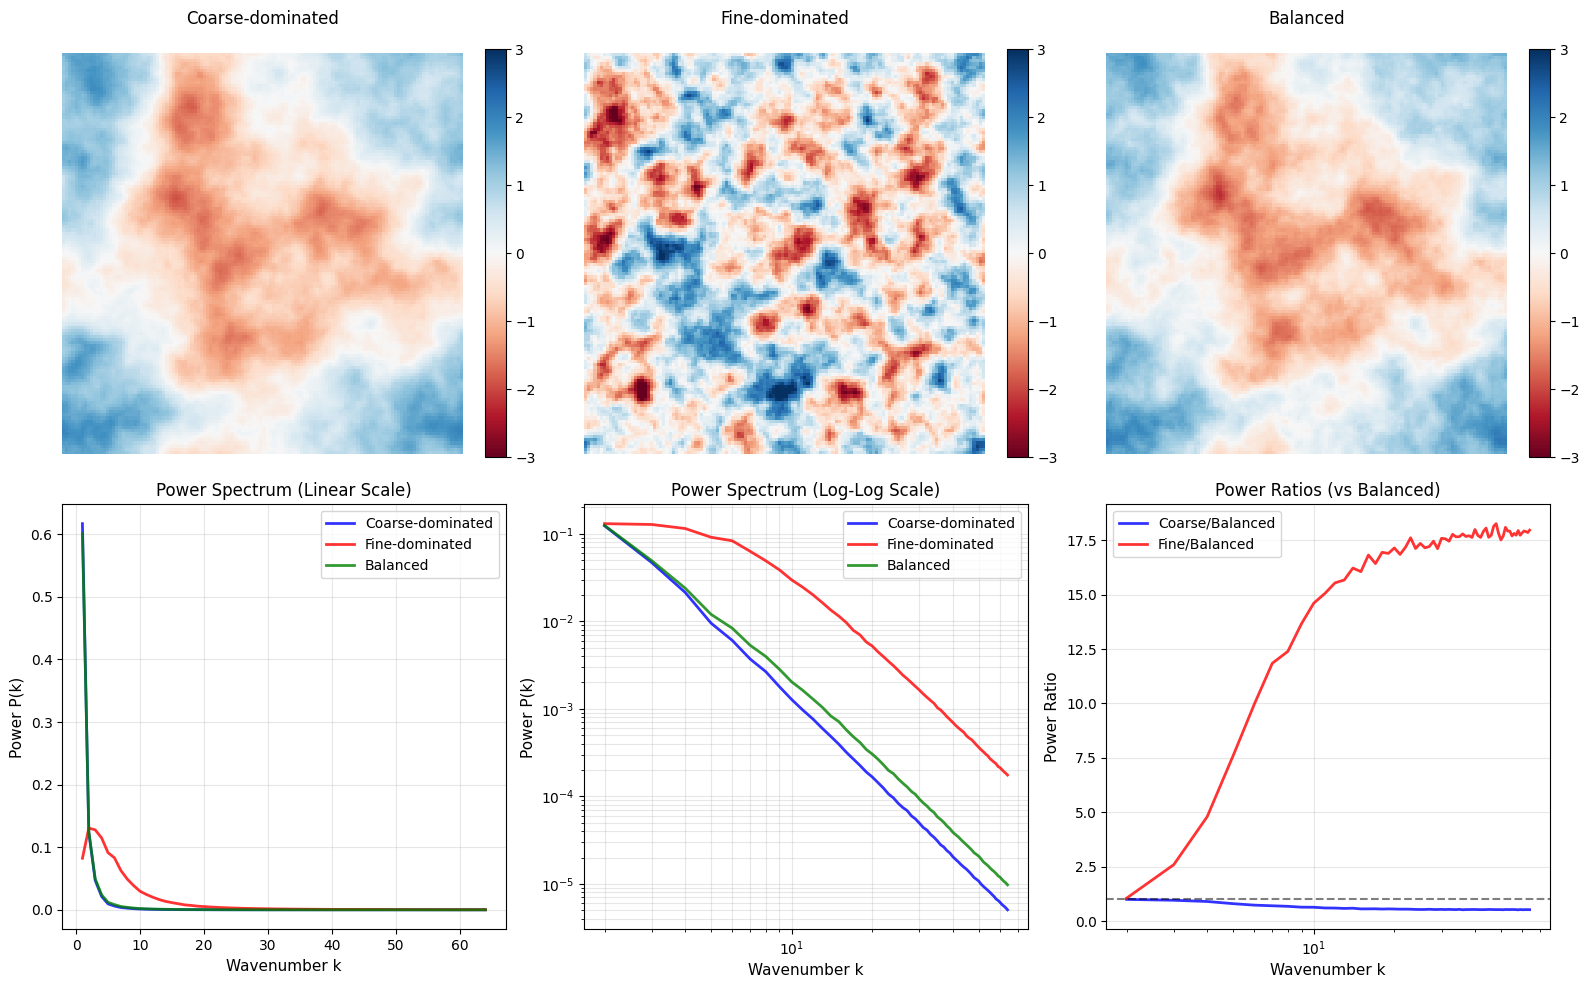


=== Dataset Statistics ===

Coarse-dominated:
  Mean: 0.0000, Std: 1.0000
  Total power: 0.8392

Fine-dominated:
  Mean: -0.0000, Std: 1.0000
  Total power: 0.9784

Balanced:
  Mean: 0.0000, Std: 1.0000
  Total power: 0.8434

=== Power Distribution ===
Low frequency (k<10) power fraction:
  Coarse: 0.992
  Fine: 0.798
  Balanced: 0.985

High frequency (k>20) power fraction:
  Coarse: 0.002
  Fine: 0.048
  Balanced: 0.003

=== Multiscale Parameters ===
Coarse params: {'length_scale': 2.0, 's': 2.0, 'sigma_sq': 1.0}
Fine params: {'length_scale': 30.0, 's': 2.0, 'sigma_sq': 1.0}
Mix coefficients: coarse=1.0, fine=0.6

=== Fourier Decomposition Verification ===
Mean reconstruction error in Fourier space: 6.76e-07
(Should be very small, close to 0)


In [57]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

coarse_params = {
    'length_scale': 2.0,  # Large length scale for coarse features
    's': 2.0,
    'sigma_sq': 1.0,
}

fine_params = {
    'length_scale': 30.0,   # Small length scale for fine features
    's': 2.0,
    'sigma_sq': 1.0,
}

# Generate the multiscale dataset with spectra tracking
num_samples = 100
grid_size = 128
seed = 42

# Generate the combined multiscale field
result = generate_multiscale_dataset_with_spectra(
    num_samples=num_samples,
    grid_size=grid_size,
    coarse_params=coarse_params,
    fine_params=fine_params,
    mix_coarse=1.0,
    mix_fine=1.0,
    seed=seed,
    normalize=True,
)

# Extract the components
x_multiscale = result['combined']
x_coarse_component = result['coarse']
x_fine_component = result['fine']

# For the plot_comparison function, generate pure versions
# (coarse-only and fine-only) by using mix coefficients
x_coarse_only = generate_multiscale_dataset_with_spectra(
    num_samples=num_samples,
    grid_size=grid_size,
    coarse_params=coarse_params,
    fine_params=fine_params,
    mix_coarse=1.0,
    mix_fine=0.0,  # No fine component
    seed=seed,
    normalize=True,
)['combined']

x_fine_only = generate_multiscale_dataset_with_spectra(
    num_samples=num_samples,
    grid_size=grid_size,
    coarse_params=coarse_params,
    fine_params=fine_params,
    mix_coarse=0.0,  # No coarse component
    mix_fine=1.0,
    seed=seed,
    normalize=True,
)['combined']

# Plot the comparison
plot_comparison(
    x_coarse=x_coarse_only,
    x_fine=x_fine_only,
    x_balanced=x_multiscale,
    coarse_params=coarse_params,
    fine_params=fine_params
)

print("\n=== Multiscale Parameters ===")
print(f"Coarse params: {coarse_params}")
print(f"Fine params: {fine_params}")
print(f"Mix coefficients: coarse={1.0}, fine={0.6}")

# You can also verify the Fourier decomposition holds
print("\n=== Fourier Decomposition Verification ===")
coarse_fft = result['coarse_fft']
fine_fft = result['fine_fft']
combined_fft = result['combined_fft']

# Check if mix_coarse * coarse_fft + mix_fine * fine_fft ≈ combined_fft
reconstructed_fft = 1.0 * coarse_fft + 1.0 * fine_fft
error = torch.abs(reconstructed_fft - combined_fft).mean()
print(f"Mean reconstruction error in Fourier space: {error.item():.2e}")
print("(Should be very small, close to 0)")

In [74]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def _fft2(x):
    # x: (B,H,W) real
    return torch.fft.fft2(x, dim=(-2, -1), norm="forward")

def _ifft2(X):
    # X: (B,H,W) complex
    return torch.fft.ifft2(X, dim=(-2, -1), norm="forward").real

def _fftshift2(X):
    return torch.fft.fftshift(X, dim=(-2, -1))

def power_spectrum_2d(x, eps=1e-12):
    """
    Returns shifted log-power image for visualization.
    x: (B,H,W) real
    """
    X = _fft2(x)
    P = (X.abs() ** 2)
    P = _fftshift2(P.mean(dim=0))  # (H,W)
    return torch.log10(P + eps)

def radial_profile(P):
    """
    Radially average a 2D power image (H,W) over k = sqrt(kx^2+ky^2).
    Returns (k_bins, P_radial).
    """
    H, W = P.shape
    assert H == W, "radial_profile expects square"
    N = H

    # k grid: centered
    k = np.fft.fftfreq(N) * N
    kx, ky = np.meshgrid(k, k, indexing="ij")
    kr = np.sqrt(kx**2 + ky**2)

    kr_flat = kr.reshape(-1)
    P_flat = P.detach().cpu().numpy().reshape(-1)

    # integer bins
    kmax = int(kr_flat.max())
    bins = np.arange(0, kmax + 1)
    P_rad = np.zeros_like(bins, dtype=np.float64)
    counts = np.zeros_like(bins, dtype=np.int64)

    idx = np.clip(kr_flat.astype(int), 0, kmax)
    np.add.at(P_rad, idx, P_flat)
    np.add.at(counts, idx, 1)
    P_rad = P_rad / np.maximum(counts, 1)

    return bins, P_rad

def bandpower_fraction(x, kmin, kmax, eps=1e-12):
    """
    Fraction of total power contained in k in [kmin,kmax] (radial bins).
    x: (B,H,W) real
    """
    X = _fft2(x)
    P = (X.abs() ** 2).mean(dim=0)  # (H,W) unshifted is fine for radial
    k_bins, P_rad = radial_profile(P)

    total = P_rad.sum() + eps
    mask = (k_bins >= kmin) & (k_bins <= kmax)
    return float(P_rad[mask].sum() / total)

def plot_field(x, title="", cmap="RdBu"):
    # x: (H,W) or (B,H,W) -> show first
    if x.ndim == 3:
        x = x[0]
    plt.figure(figsize=(5,5))
    plt.imshow(x.detach().cpu().numpy(), cmap=cmap)
    plt.colorbar(shrink=0.75)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def plot_spectrum_image(x, title="log10 power spectrum"):
    P_log = power_spectrum_2d(x)
    plt.figure(figsize=(5,5))
    plt.imshow(P_log.detach().cpu().numpy())
    plt.colorbar(shrink=0.75)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def plot_radial_spectra(xs, labels, title="Radially-averaged power spectrum", ylog=True):
    plt.figure(figsize=(6,4))
    for x, lab in zip(xs, labels):
        X = _fft2(x)
        P = (X.abs()**2).mean(dim=0)
        k, Pr = radial_profile(P)
        plt.plot(k, Pr, label=lab)
    if ylog:
        plt.yscale("log")
    plt.xlabel("k (radial bin)")
    plt.ylabel("Power")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [76]:
import math

def make_radial_k_grid(N, device=None):
    k = torch.fft.fftfreq(N, d=1.0, device=device) * N  # cycles/sample * N
    kx, ky = torch.meshgrid(k, k, indexing="ij")
    return torch.sqrt(kx**2 + ky**2)  # (N,N)

def ring_mask(N, k0, width, device=None):
    kr = make_radial_k_grid(N, device=device)
    return ((kr >= (k0 - width/2)) & (kr <= (k0 + width/2))).to(torch.float32)

def band_mask(N, kmin, kmax, device=None):
    kr = make_radial_k_grid(N, device=device)
    return ((kr >= kmin) & (kr <= kmax)).to(torch.float32)

def make_bandlimited_pattern(N, mask, seed=0, device=None):
    """
    Create a REAL band-limited spatial pattern by:
      w ~ N(0,1) in space -> FFT -> keep only masked freqs -> iFFT -> normalize.
    mask: (N,N) float in {0,1} (unshifted freq layout)
    """
    g = torch.Generator(device=device)
    g.manual_seed(int(seed))

    w = torch.randn(N, N, generator=g, device=device)
    W = torch.fft.fft2(w, norm="forward")
    W_f = W * mask  # band-limit in Fourier domain
    p = torch.fft.ifft2(W_f, norm="forward").real

    p = p - p.mean()
    p = p / (p.std().clamp_min(1e-8))
    return p  # (N,N) real, unit std

def bias_fourier_watermark(x, kmin=None, kmax=None, k0=None, width=None,
                           strength=0.10, seed=123):
    """
    Add a *shared* band-limited watermark to every sample.
    x: (B,N,N) real
    Choose either:
      - (kmin,kmax) band, or
      - (k0,width) ring.
    strength is in units of x std (roughly).
    """
    B, N, _ = x.shape
    device = x.device

    if (k0 is not None) and (width is not None):
        m = ring_mask(N, k0=k0, width=width, device=device)
    else:
        assert (kmin is not None) and (kmax is not None), "Provide (kmin,kmax) or (k0,width)"
        m = band_mask(N, kmin=kmin, kmax=kmax, device=device)

    p = make_bandlimited_pattern(N, m, seed=seed, device=device)  # (N,N)
    return x + strength * p.unsqueeze(0)  # broadcast

def bias_spike_code(x, spikes, strength=0.05):
    """
    Add a deterministic spike-code watermark: sum cos(2π(k·r)) patterns.
    spikes: list of (kx,ky) integers in fftfreq*N coordinates (e.g., (23,7))
    """
    B, N, _ = x.shape
    device = x.device

    # spatial grid in [0,1)
    u = torch.arange(N, device=device) / N
    Xg, Yg = torch.meshgrid(u, u, indexing="ij")

    patt = torch.zeros(N, N, device=device)
    for kx, ky in spikes:
        patt = patt + torch.cos(2*math.pi*(kx*Xg + ky*Yg))

    patt = patt - patt.mean()
    patt = patt / patt.std().clamp_min(1e-8)
    return x + strength * patt.unsqueeze(0)

def bias_spatial_stamp(x, top=0, left=0, size=8, strength=0.20, mode="checker"):
    """
    Add a small stamp in pixel space.
    mode: "constant" or "checker"
    strength in units of x std-ish.
    """
    B, N, _ = x.shape
    device = x.device

    stamp = torch.zeros(N, N, device=device)
    if mode == "constant":
        stamp[top:top+size, left:left+size] = 1.0
    elif mode == "checker":
        yy, xx = torch.meshgrid(torch.arange(size, device=device),
                                torch.arange(size, device=device), indexing="ij")
        stamp[top:top+size, left:left+size] = ((xx + yy) % 2).float() * 2 - 1
    else:
        raise ValueError("mode must be 'constant' or 'checker'")

    stamp = stamp - stamp.mean()
    stamp = stamp / stamp.std().clamp_min(1e-8)
    return x + strength * stamp.unsqueeze(0)

def apply_canary(x, bias_fn, p=0.1, seed=0, **bias_kwargs):
    """
    Apply bias only to a random subset of samples (canary).
    Returns (x_biased, mask_indices_bool).
    """
    B = x.shape[0]
    g = torch.Generator(device=x.device)
    g.manual_seed(int(seed))
    idx = torch.rand(B, generator=g, device=x.device) < p

    x2 = x.clone()
    if idx.any():
        x2[idx] = bias_fn(x2[idx], **bias_kwargs)
    return x2, idx

def add_bias_to_multiscale_dict(ds, target="combined", bias_type="fourier_watermark", **kwargs):
    """
    ds: dict from generate_multiscale_dataset_with_spectra
    target: 'combined' (recommended), or 'coarse', 'fine'
    Returns a NEW dict with extra keys for biased outputs/ffts.
    """
    out = dict(ds)  # shallow copy
    x = out[target]

    if bias_type == "fourier_watermark":
        xb = bias_fourier_watermark(x, **kwargs)
        canary_mask = None
    elif bias_type == "spike_code":
        xb = bias_spike_code(x, **kwargs)
        canary_mask = None
    elif bias_type == "spatial_stamp":
        xb = bias_spatial_stamp(x, **kwargs)
        canary_mask = None
    elif bias_type == "canary_fourier":
        xb, canary_mask = apply_canary(x, bias_fourier_watermark, **kwargs)
    elif bias_type == "canary_spike":
        xb, canary_mask = apply_canary(x, bias_spike_code, **kwargs)
    elif bias_type == "canary_stamp":
        xb, canary_mask = apply_canary(x, bias_spatial_stamp, **kwargs)
    else:
        raise ValueError(f"Unknown bias_type: {bias_type}")

    out[f"{target}_biased"] = xb
    out[f"{target}_biased_fft"] = torch.fft.fft2(xb, dim=(-2, -1), norm="forward")
    out["bias_meta"] = {"target": target, "bias_type": bias_type, **kwargs}
    if canary_mask is not None:
        out["canary_mask"] = canary_mask
    return out


In [78]:
def visualize_bias(x, xb, title_prefix="", k_band=None):
    """
    x, xb: (B,N,N)
    k_band: tuple (kmin,kmax) for bandpower metric display
    """
    # spatial
    plot_field(x,  title=f"{title_prefix}original (sample 0)")
    plot_field(xb, title=f"{title_prefix}biased (sample 0)")
    plot_field(xb - x, title=f"{title_prefix}bias residual (biased - original)")

    # spectrum images
    plot_spectrum_image(x,  title=f"{title_prefix}original log10 power")
    plot_spectrum_image(xb, title=f"{title_prefix}biased log10 power")

    # radial spectra
    plot_radial_spectra([x, xb], ["original", "biased"],
                        title=f"{title_prefix}radial power spectrum", ylog=True)

    # bandpower numbers
    if k_band is not None:
        kmin, kmax = k_band
        f0 = bandpower_fraction(x,  kmin, kmax)
        f1 = bandpower_fraction(xb, kmin, kmax)
        print(f"Bandpower fraction k∈[{kmin},{kmax}]: original={f0:.4f}, biased={f1:.4f}, Δ={f1-f0:+.4f}")

def canary_prevalence_estimate(xb, k_band, threshold_sigma=3.0):
    """
    For canary bias: estimate how many samples look 'watermarked' by bandpower z-score.
    xb: (B,N,N)
    """
    B = xb.shape[0]
    kmin, kmax = k_band

    # compute per-sample bandpower fraction
    vals = []
    for i in range(B):
        vals.append(bandpower_fraction(xb[i:i+1], kmin, kmax))
    vals = np.array(vals)

    z = (vals - vals.mean()) / (vals.std() + 1e-12)
    flagged = (z > threshold_sigma).mean()
    return vals, z, flagged


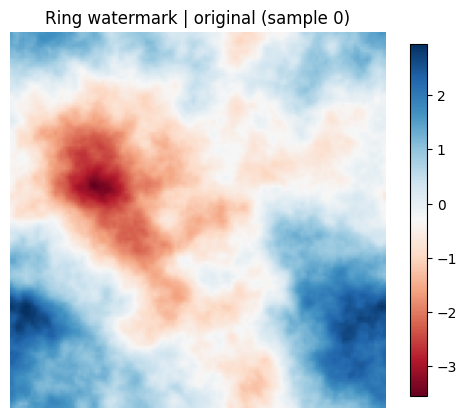

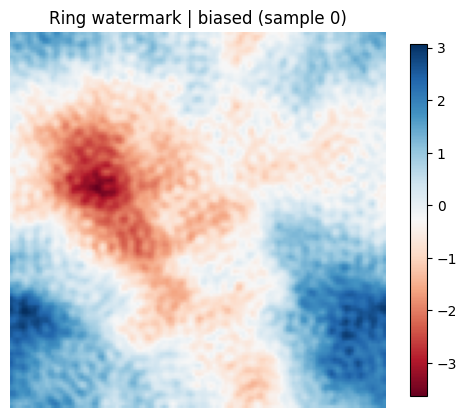

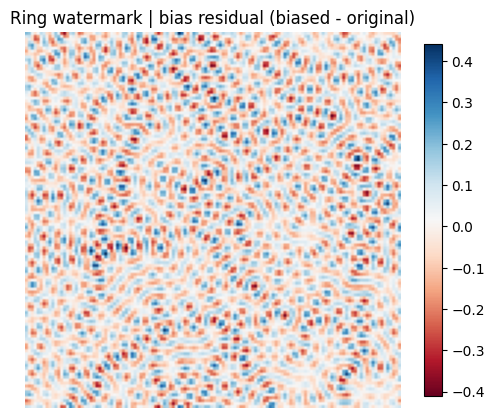

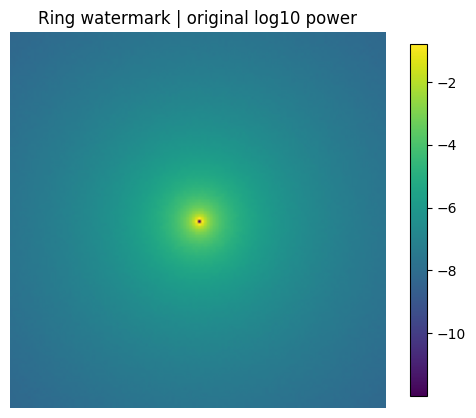

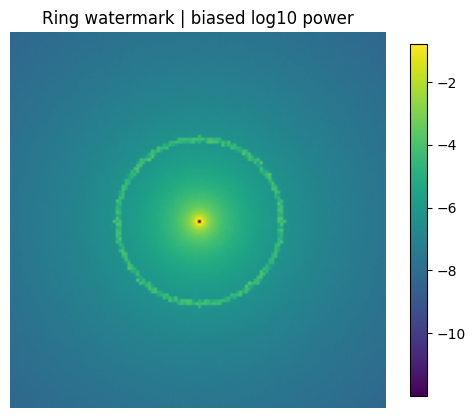

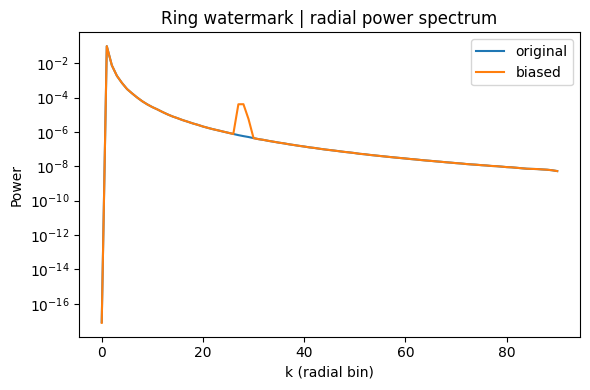

Bandpower fraction k∈[27,29]: original=0.0000, biased=0.0008, Δ=+0.0008


In [79]:
ds = generate_multiscale_dataset_with_spectra(
    num_samples=256, grid_size=128,
    coarse_params=coarse_params, fine_params=fine_params,
    mix_coarse=1.0, mix_fine=1.0, seed=42, normalize=True
)

dsb = add_bias_to_multiscale_dict(
    ds, target="combined", bias_type="fourier_watermark",
    k0=28, width=2, strength=0.12, seed=999
)

visualize_bias(ds["combined"], dsb["combined_biased"], title_prefix="Ring watermark | ",
               k_band=(27,29))


In [80]:
# Check if bias is actually in the right frequency band
X_orig = torch.fft.fft2(ds["combined"], norm="forward")
X_bias = torch.fft.fft2(dsb["combined_biased"], norm="forward")
X_diff = X_bias - X_orig

# Power in the ring
kr = make_radial_k_grid(128, device=ds["combined"].device)
ring_mask_check = ((kr >= 27) & (kr <= 29))
power_in_ring = (X_diff.abs()**2 * ring_mask_check).sum()
power_outside_ring = (X_diff.abs()**2 * ~ring_mask_check).sum()

print(f"Power ratio (in ring / outside): {power_in_ring / power_outside_ring:.2f}")
# Should be >> 1 if bias is correctly localized

Power ratio (in ring / outside): 669925310464.00


In [85]:
import os
import json
import torch

def _to_cpu_f32(x: torch.Tensor) -> torch.Tensor:
    """Move tensor to CPU float32 for portable saving."""
    if not torch.is_tensor(x):
        return x
    if x.is_complex():
        # keep complex as complex64 on CPU (FFT outputs)
        return x.detach().to("cpu").to(torch.complex64)
    return x.detach().to("cpu").to(torch.float32)

def _pack_ds_for_saving(ds: dict, include_fft: bool = False) -> dict:
    """
    ds: dict returned by generate_multiscale_dataset_with_spectra or add_bias_to_multiscale_dict
    Returns a smaller, save-friendly dict.
    """
    packed = {
        # core fields you’ll actually train on / compare against
        "combined": _to_cpu_f32(ds.get("combined")),
        "coarse": _to_cpu_f32(ds.get("coarse")),
        "fine": _to_cpu_f32(ds.get("fine")),
        "normalization": ds.get("normalization"),
    }

    # biased outputs (only present after add_bias_to_multiscale_dict)
    if "combined_biased" in ds:
        packed["combined_biased"] = _to_cpu_f32(ds["combined_biased"])
    if "bias_meta" in ds:
        packed["bias_meta"] = ds["bias_meta"]
    if "canary_mask" in ds:
        packed["canary_mask"] = _to_cpu_f32(ds["canary_mask"])

    # optional: FFTs (large + complex, but useful for debugging memorisation in Fourier space)
    if include_fft:
        for k in ["coarse_fft", "fine_fft", "combined_fft", "combined_biased_fft"]:
            if k in ds:
                packed[k] = _to_cpu_f32(ds[k])

    return packed

def generate_and_save_unbiased_biased(
    save_path: str,
    *,
    num_samples: int,
    grid_size: int,
    coarse_params: dict,
    fine_params: dict,
    mix_coarse: float = 1.0,
    mix_fine: float = 1.0,
    seed: int | None = None,
    normalize: bool = True,
    # bias config: match your notebook call to add_bias_to_multiscale_dict
    target: str = "combined",
    bias_type: str = "fourier_watermark",
    bias_kwargs: dict | None = None,
    include_fft: bool = False,
):
    """
    Saves a single .pt file containing:
      - unbiased dataset (from generate_multiscale_dataset_with_spectra)
      - biased dataset (from add_bias_to_multiscale_dict applied to the same ds)
      - config metadata for reproducibility
    """
    if bias_kwargs is None:
        bias_kwargs = {}

    # 1) generate unbiased
    ds = generate_multiscale_dataset_with_spectra(
        num_samples=num_samples,
        grid_size=grid_size,
        coarse_params=coarse_params,
        fine_params=fine_params,
        mix_coarse=mix_coarse,
        mix_fine=mix_fine,
        seed=seed,
        normalize=normalize,
    )

    # 2) generate biased (same underlying ds, so comparisons are clean)
    dsb = add_bias_to_multiscale_dict(
        ds,
        target=target,
        bias_type=bias_type,
        **bias_kwargs,
    )

    # 3) pack and save
    bundle = {
        "config": {
            "num_samples": num_samples,
            "grid_size": grid_size,
            "coarse_params": coarse_params,
            "fine_params": fine_params,
            "mix_coarse": mix_coarse,
            "mix_fine": mix_fine,
            "seed": seed,
            "normalize": normalize,
            "target": target,
            "bias_type": bias_type,
            "bias_kwargs": bias_kwargs,
            "include_fft": include_fft,
        },
        "unbiased": _pack_ds_for_saving(ds, include_fft=include_fft),
        "biased": _pack_ds_for_saving(dsb, include_fft=include_fft),
    }

    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
    torch.save(bundle, save_path)
    return save_path

import torch

def load_saved_bundle(pt_path: str, device: str = "auto"):
    """
    device:
      - "auto": use cuda if available else cpu
      - "cpu" / "cuda"
    Returns (bundle, x_unbiased, x_biased) with x shaped (B,1,H,W).
    """
    if device == "auto":
        device = "cuda" if torch.cuda.is_available() else "cpu"
    elif device == "cuda" and not torch.cuda.is_available():
        print("CUDA not available, falling back to CPU.")
        device = "cpu"

    # Always load from disk to CPU storages first (portable)
    bundle = torch.load(pt_path, map_location="cpu")

    x_unbiased = bundle["unbiased"]["combined"].unsqueeze(1).to(device)          # (B,1,H,W)
    x_biased   = bundle["biased"]["combined_biased"].unsqueeze(1).to(device)     # (B,1,H,W)

    return bundle, x_unbiased, x_biased, device


In [87]:
coarse_params = {"length_scale": 2.0, "s": 2.0, "sigma_sq": 1.0}
fine_params   = {"length_scale": 30.0, "s": 2.0, "sigma_sq": 1.0}

save_path = generate_and_save_unbiased_biased(
    "results/data/multiband_dataset_unbiased_and_biased.pt",
    num_samples=10_000,
    grid_size=128,
    coarse_params=coarse_params,
    fine_params=fine_params,
    mix_coarse=1.0,
    mix_fine=1.0,
    seed=42,
    normalize=True,
    target="combined",
    bias_type="fourier_watermark",
    bias_kwargs={"k0": 28, "width": 2, "strength": 0.12, "seed": 999},
    include_fft=False,  # set True if you want FFTs saved too
)

bundle, x_unbiased, x_biased, device = load_saved_bundle(save_path, device="auto")
print("device:", device)
print(x_unbiased.shape, x_biased.shape)


device: cpu
torch.Size([10000, 1, 128, 128]) torch.Size([10000, 1, 128, 128])
